In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import LinearSVC
from sklearn.neighbors import KNeighborsClassifier
df=pd.read_csv(r"F:\New folder (2)\intrusiondetection.csv", low_memory=False)
df

,duration,protocol_type,service,flag,src_bytes,dst_bytes,logged_in,count,same_srv_rate,serror_rate,srv_serror_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_srv_count,label
0,0,tcp,ftp_data,SF,491,0,0,2,1.00,0.0,0.0,0.03,0.17,0.00,25,normal
1,0,udp,other,SF,146,0,0,13,0.08,0.0,0.0,0.60,0.88,0.00,1,normal
2,0,tcp,private,S0,0,0,0,123,0.05,1.0,1.0,0.05,0.00,0.00,26,neptune
3,0,tcp,http,SF,232,8153,1,5,1.00,0.2,0.2,0.00,0.03,0.04,255,normal
4,0,tcp,http,SF,199,420,1,30,1.00,0.0,0.0,0.00,0.00,0.00,255,normal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25187,0,tcp,exec,RSTO,0,0,0,100,0.07,0.0,0.0,0.06,0.00,0.00,7,neptune
25188,0,tcp,ftp_data,SF,334,0,1,1,1.00,0.0,0.0,0.00,1.00,0.18,39,warezclient
25189,0,tcp,private,REJ,0,0,0,105,0.07,0.0,0.0,0.07,0.00,0.00,13,neptune
25190,0,tcp,nnsp,S0,0,0,0,129,0.14,1.0,1.0,0.06,0.00,0.00,20,neptune


In [2]:
df.head(10)

,duration,protocol_type,service,flag,src_bytes,dst_bytes,logged_in,count,same_srv_rate,serror_rate,srv_serror_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_srv_count,label
0,0,tcp,ftp_data,SF,491,0,0,2,1.00,0.0,0.0,0.03,0.17,0.00,25,normal
1,0,udp,other,SF,146,0,0,13,0.08,0.0,0.0,0.60,0.88,0.00,1,normal
2,0,tcp,private,S0,0,0,0,123,0.05,1.0,1.0,0.05,0.00,0.00,26,neptune
3,0,tcp,http,SF,232,8153,1,5,1.00,0.2,0.2,0.00,0.03,0.04,255,normal
4,0,tcp,http,SF,199,420,1,30,1.00,0.0,0.0,0.00,0.00,0.00,255,normal
5,0,tcp,private,REJ,0,0,0,121,0.16,0.0,0.0,0.07,0.00,0.00,19,neptune
6,0,tcp,private,S0,0,0,0,166,0.05,1.0,1.0,0.05,0.00,0.00,9,neptune
7,0,tcp,private,S0,0,0,0,117,0.14,1.0,1.0,0.07,0.00,0.00,15,neptune
8,0,tcp,remote_job,S0,0,0,0,270,0.09,1.0,1.0,0.05,0.00,0.00,23,neptune
9,0,tcp,private,S0,0,0,0,133,0.06,1.0,1.0,0.06,0.00,0.00,13,neptune


In [3]:
df.shape

(25192, 16)

In [4]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 25192 entries, 0 to 25191
Data columns (total 16 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   duration                     25192 non-null  int64  
 1   protocol_type                25192 non-null  str    
 2   service                      25192 non-null  str    
 3   flag                         25192 non-null  str    
 4   src_bytes                    25192 non-null  int64  
 5   dst_bytes                    25192 non-null  int64  
 6   logged_in                    25192 non-null  int64  
 7   count                        25192 non-null  int64  
 8   same_srv_rate                25192 non-null  float64
 9   serror_rate                  25192 non-null  float64
 10  srv_serror_rate              25192 non-null  float64
 11  dst_host_diff_srv_rate       25192 non-null  float64
 12  dst_host_same_src_port_rate  25192 non-null  float64
 13  dst_host_srv_diff_host_rate

In [5]:
df.describe()

,duration,src_bytes,dst_bytes,logged_in,count,same_srv_rate,serror_rate,srv_serror_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_srv_count
count,25192.000000,2.519200e+04,2.519200e+04,25192.000000,25192.000000,25192.000000,25192.000000,25192.000000,25192.000000,25192.000000,25192.000000,25192.000000
mean,305.054104,2.433063e+04,3.491847e+03,0.394768,84.591180,0.660559,0.286338,0.283762,0.082539,0.147453,0.031844,115.063036
std,2686.555640,2.410805e+06,8.883072e+04,0.488811,114.673451,0.439637,0.447312,0.447599,0.187191,0.308367,0.110575,110.646850
min,0.000000,0.000000e+00,0.000000e+00,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000e+00,0.000000e+00,0.000000,2.000000,0.090000,0.000000,0.000000,0.000000,0.000000,0.000000,10.000000
50%,0.000000,4.400000e+01,0.000000e+00,0.000000,14.000000,1.000000,0.000000,0.000000,0.030000,0.000000,0.000000,61.000000
75%,0.000000,2.790000e+02,5.302500e+02,1.000000,144.000000,1.000000,1.000000,1.000000,0.070000,0.060000,0.020000,255.000000
max,42862.000000,3.817091e+08,5.151385e+06,1.000000,511.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,255.000000


In [6]:
df.isnull().sum()


duration                       0
protocol_type                  0
service                        0
flag                           0
src_bytes                      0
dst_bytes                      0
logged_in                      0
count                          0
same_srv_rate                  0
serror_rate                    0
srv_serror_rate                0
dst_host_diff_srv_rate         0
dst_host_same_src_port_rate    0
dst_host_srv_diff_host_rate    0
dst_host_srv_count             0
label                          0
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(663)

In [8]:
df.drop_duplicates(inplace=True)

In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df.label.unique()


<ArrowStringArray>
[         'normal',         'neptune',     'warezclient',         'ipsweep',
       'portsweep',        'teardrop',            'nmap',           'satan',
           'smurf',             'pod',            'back',    'guess_passwd',
       'ftp_write',        'multihop',         'rootkit', 'buffer_overflow',
            'imap',     'warezmaster',             'phf',            'land',
      'loadmodule',             'spy']
Length: 22, dtype: str

In [11]:
attack_mapping = {
    'normal': 'Normal',

    'back': 'DoS',
    'land': 'DoS',
    'neptune': 'DoS',
    'pod': 'DoS',
    'smurf': 'DoS',
    'teardrop': 'DoS',

    'ipsweep': 'Probe',
    'nmap': 'Probe',
    'portsweep': 'Probe',
    'satan': 'Probe',

    'ftp_write': 'R2L',
    'guess_passwd': 'R2L',
    'imap': 'R2L',
    'multihop': 'R2L',
    'phf': 'R2L',
    'spy': 'R2L',
    'warezclient': 'R2L',
    'warezmaster': 'R2L',

    'buffer_overflow': 'U2R',
    'loadmodule': 'U2R',
    'perl': 'U2R',
    'rootkit': 'U2R'
}

In [12]:
df.label=df.label.map(attack_mapping)

In [13]:
df["label"].unique()

<ArrowStringArray>
['Normal', 'DoS', 'R2L', 'Probe', 'U2R']
Length: 5, dtype: str

In [14]:
df.to_csv("C:/Users/DELL/Downloads/Updated_data.csv",index=False)

In [15]:
df.label=df.label.map({
    "Normal":0,
    "DoS":1,
    "R2L":2,
    "Probe":3,
    "U2R":4
})

In [16]:
df.label.unique()

array([0, 1, 2, 3, 4])

In [17]:
from sklearn.preprocessing import LabelEncoder

protocol_encoder = LabelEncoder()

df['protocol_type'] = protocol_encoder.fit_transform(df['protocol_type'])

In [18]:
service_encoder= LabelEncoder()

df['service'] = service_encoder.fit_transform(df['service'])

In [19]:
flag_encoder= LabelEncoder()

df['flag'] = flag_encoder.fit_transform(df['flag'])

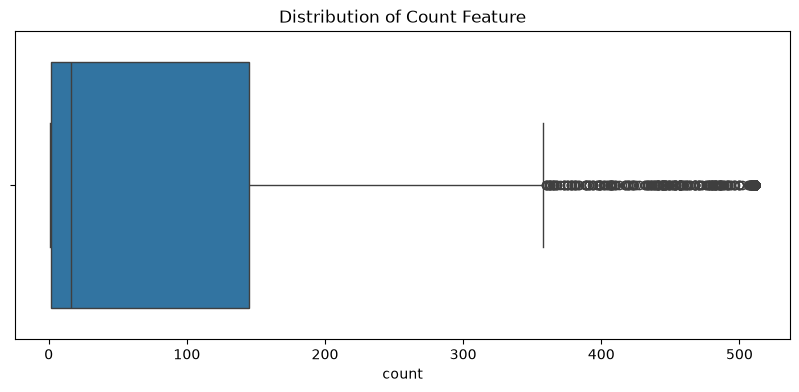

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(10,4))
sns.boxplot(x="count", data=df)
plt.title("Distribution of Count Feature")
plt.show()

<Axes: >

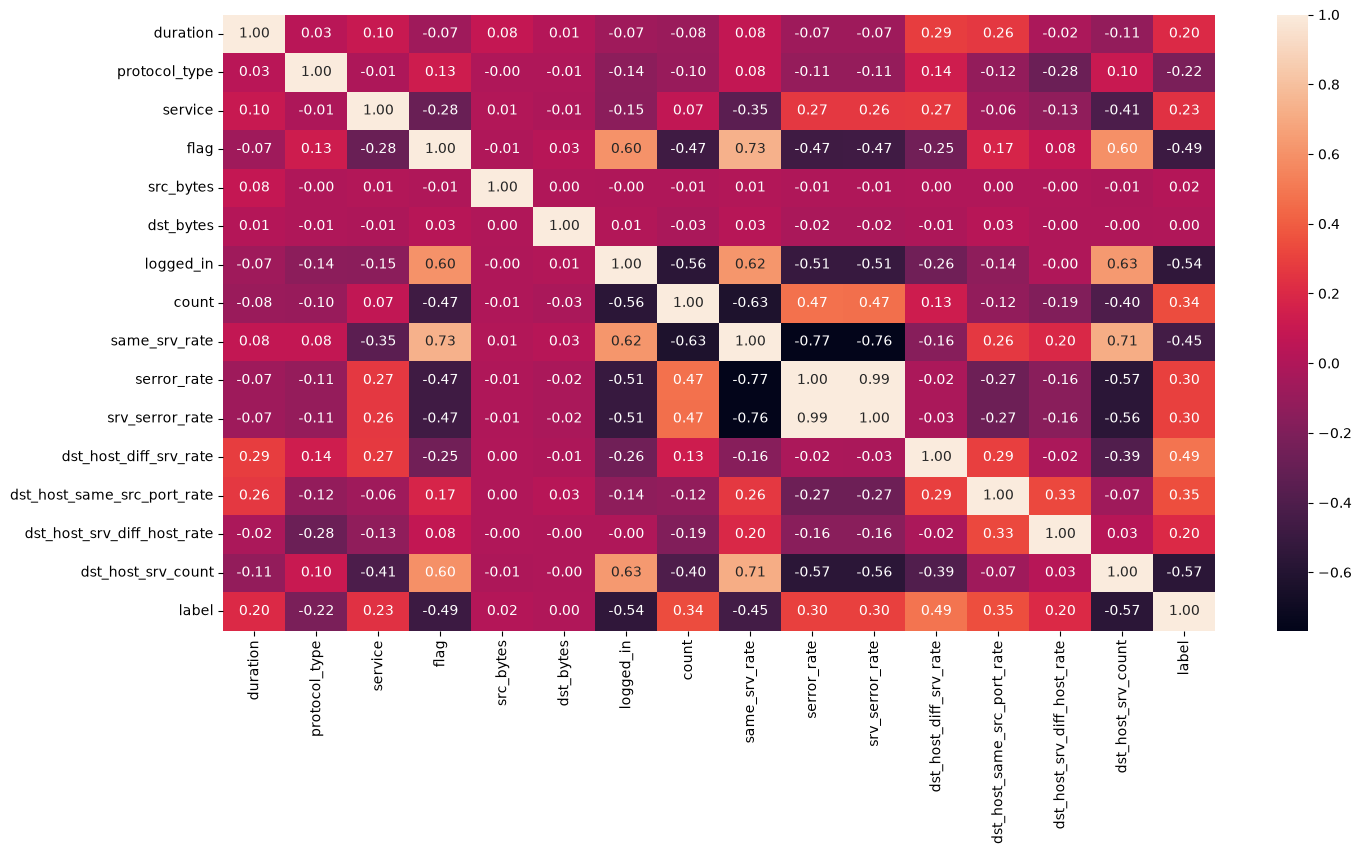

In [21]:
import matplotlib.pyplot as plt

plt.figure(figsize=(16,8))
sns.heatmap(
    df.select_dtypes(include='number').corr(),
    annot=True,fmt=".2f"
)

In [22]:
# Features (Input)
x = df.drop(columns=["label"])

# Target (Output)
y = df["label"]

In [23]:
x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [24]:
logistic_model = LogisticRegression(
    max_iter=2000,
    class_weight="balanced",
    random_state=42
)

logistic_model.fit(x_train, y_train)

y_pred_lr = logistic_model.predict(x_test)

score1 = accuracy_score(y_test, y_pred_lr)

print("Logistic Regression Accuracy:", score1)
print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred_lr,
    target_names=["Normal", "DoS", "R2L", "Probe", "U2R"],
    zero_division=0
))

Logistic Regression Accuracy: 0.8514064410925397

Classification Report:
              precision    recall  f1-score   support

      Normal       0.90      0.90      0.90      2674
         DoS       0.84      0.94      0.89      1835
         R2L       0.00      0.00      0.00        41
       Probe       0.66      0.14      0.22       354
         U2R       0.04      1.00      0.08         2

    accuracy                           0.85      4906
   macro avg       0.49      0.59      0.42      4906
weighted avg       0.85      0.85      0.84      4906



e:\python\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 2000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=2000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [25]:
print(df.shape)

(24529, 16)


In [26]:
decision_tree = DecisionTreeClassifier(
    random_state=42,
    class_weight="balanced"
)

decision_tree.fit(x_train, y_train)

y_pred_dt = decision_tree.predict(x_test)

score2 = accuracy_score(y_test, y_pred_dt)

print("Decision Tree Accuracy:", score2)
print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred_dt,
    target_names=["Normal", "DoS", "R2L", "Probe", "U2R"],
    zero_division=0
))

Decision Tree Accuracy: 0.9947003668976763

Classification Report:
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00      2674
         DoS       1.00      1.00      1.00      1835
         R2L       0.86      0.93      0.89        41
       Probe       0.99      0.97      0.98       354
         U2R       0.50      0.50      0.50         2

    accuracy                           0.99      4906
   macro avg       0.87      0.88      0.87      4906
weighted avg       0.99      0.99      0.99      4906



In [27]:
random_forest = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)

random_forest.fit(x_train, y_train)

y_pred_rf = random_forest.predict(x_test)

score3 = accuracy_score(y_test, y_pred_rf)

print("Random Forest Accuracy:", score3)

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))

print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred_rf,
    target_names=["Normal", "DoS", "R2L", "Probe", "U2R"],
    zero_division=0
))

Random Forest Accuracy: 0.9981655116184264

Confusion Matrix:
[[2669    2    0    3    0]
 [   0 1834    0    1    0]
 [   1    0   40    0    0]
 [   2    0    0  352    0]
 [   0    0    0    0    2]]

Classification Report:
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00      2674
         DoS       1.00      1.00      1.00      1835
         R2L       1.00      0.98      0.99        41
       Probe       0.99      0.99      0.99       354
         U2R       1.00      1.00      1.00         2

    accuracy                           1.00      4906
   macro avg       1.00      0.99      1.00      4906
weighted avg       1.00      1.00      1.00      4906



In [28]:
NV_model = GaussianNB()

NV_model.fit(x_train, y_train)

y_pred_nb = NV_model.predict(x_test)

score4 = accuracy_score(y_test, y_pred_nb)

print("Naive Bayes Accuracy:", score4)

print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred_nb,
    target_names=["Normal", "DoS", "R2L", "Probe", "U2R"],
    zero_division=0
))

Naive Bayes Accuracy: 0.462291072156543

Classification Report:
              precision    recall  f1-score   support

      Normal       0.93      0.16      0.27      2674
         DoS       0.42      0.98      0.59      1835
         R2L       0.00      0.00      0.00        41
       Probe       0.47      0.12      0.19       354
         U2R       0.00      0.00      0.00         2

    accuracy                           0.46      4906
   macro avg       0.36      0.25      0.21      4906
weighted avg       0.69      0.46      0.38      4906



In [29]:
scaler = StandardScaler()

x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

svm_model = LinearSVC(
    max_iter=20000,
    class_weight="balanced",
    random_state=42
)

svm_model.fit(x_train_scaled, y_train)

y_pred_svm = svm_model.predict(x_test_scaled)

score5 = accuracy_score(y_test, y_pred_svm)

print("SVM Accuracy:", score5)

print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred_svm,
    target_names=["Normal", "DoS", "R2L", "Probe", "U2R"],
    zero_division=0
))

SVM Accuracy: 0.9178556869139829

Classification Report:
              precision    recall  f1-score   support

      Normal       0.96      0.91      0.93      2674
         DoS       0.97      0.96      0.96      1835
         R2L       0.10      0.20      0.13        41
       Probe       0.70      0.89      0.78       354
         U2R       0.04      1.00      0.07         2

    accuracy                           0.92      4906
   macro avg       0.55      0.79      0.58      4906
weighted avg       0.94      0.92      0.93      4906



In [30]:
knn_model = KNeighborsClassifier(n_neighbors=5)

knn_model.fit(x_train, y_train)

y_pred_knn = knn_model.predict(x_test)

score6 = accuracy_score(y_test, y_pred_knn)

print("KNN Accuracy:", score6)

print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred_knn,
    target_names=["Normal", "DoS", "R2L", "Probe", "U2R"],
    zero_division=0
))

KNN Accuracy: 0.9816551161842642

Classification Report:
              precision    recall  f1-score   support

      Normal       0.99      0.99      0.99      2674
         DoS       0.98      0.99      0.99      1835
         R2L       0.81      0.95      0.88        41
       Probe       0.92      0.89      0.90       354
         U2R       0.00      0.00      0.00         2

    accuracy                           0.98      4906
   macro avg       0.74      0.76      0.75      4906
weighted avg       0.98      0.98      0.98      4906



In [31]:
results = pd.DataFrame({
    "Algorithm": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "Naive Bayes",
        "Support Vector Classifier",
        "KNN"
    ],
    "Accuracy": [
        score1,
        score2,
        score3,
        score4,
        score5,
        score6
    ]
})

results = results.sort_values(
    by="Accuracy",
    ascending=False
).reset_index(drop=True)

print(results)

                   Algorithm  Accuracy
0              Random Forest  0.998166
1              Decision Tree  0.994700
2                        KNN  0.981655
3  Support Vector Classifier  0.917856
4        Logistic Regression  0.851406
5                Naive Bayes  0.462291


In [32]:
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.ensemble import RandomForestClassifier

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

rf_cv = RandomForestClassifier(
    n_estimators=300,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

cv_results = cross_validate(
    rf_cv,
    x,
    y,
    cv=cv,
    scoring=["accuracy", "f1_macro"],
    n_jobs=-1
)

print("5-Fold Cross Validation")
print("------------------------")
print("Accuracy:", cv_results["test_accuracy"])
print("Mean Accuracy:", cv_results["test_accuracy"].mean())
print("Std Accuracy:", cv_results["test_accuracy"].std())

print("\nMacro F1:", cv_results["test_f1_macro"])
print("Mean Macro F1:", cv_results["test_f1_macro"].mean())

5-Fold Cross Validation
------------------------
Accuracy: [0.99714635 0.99694252 0.9955157  0.99612719 0.99633028]
Mean Accuracy: 0.9964124064523127
Std Accuracy: 0.0005851289574184863

Macro F1: [0.91405728 0.78941488 0.77644781 0.87666979 0.88158599]
Mean Macro F1: 0.8476351501755545


In [33]:
import joblib

joblib.dump(random_forest, "random_forest_model.joblib.pkl")
joblib.dump(protocol_encoder, "protocol_encoder.pkl")
joblib.dump(service_encoder, "service_encoder.pkl")
joblib.dump(flag_encoder, "flag_encoder.pkl")

print("✅ Final model and encoders saved successfully!")

✅ Final model and encoders saved successfully!
